# Credit Score Classification — Data Exploration & Modelling
**Final Project — Model Deployment**

**Skenario.** Sebagai data scientist di institusi keuangan, kita perlu menilai
performa kredit setiap nasabah (target `Credit_Score` dengan 3 kelas:
**Poor / Standard / Good**) menggunakan pendekatan machine learning.

Notebook ini berisi: eksplorasi data (EDA), analisis kualitas data, preprocessing,
percobaan beberapa model, dan evaluasi untuk memilih model terbaik. Pipeline
training yang reusable + tracking MLflow ada di `pipeline.py`, dan kode
inferencing/deployment ada di `inference.py` & `app.py`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('data_A.csv')
print('Shape:', df.shape)
df.head()

Shape: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


## 1. Struktur & Tipe Data

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

Dataset memiliki **25.000 baris** dan **29 kolom**. Banyak kolom numerik
terbaca sebagai `object` karena ada karakter sampah (mis. trailing `_`).

## 2. Distribusi Target (`Credit_Score`)

Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64


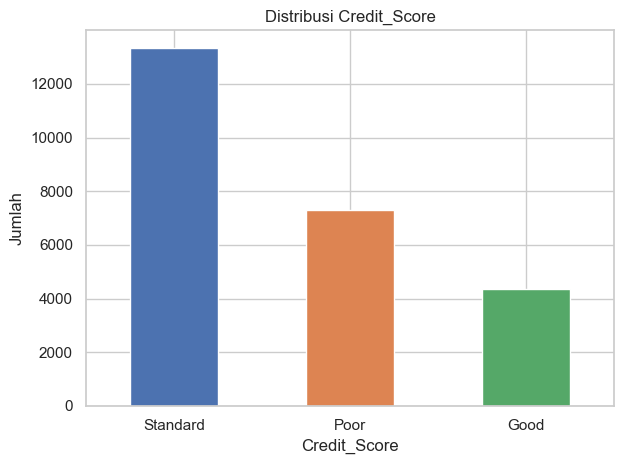

In [3]:
vc = df['Credit_Score'].value_counts()
print(vc)
ax = vc.plot(kind='bar', color=['#4c72b0','#dd8452','#55a868'])
ax.set_title('Distribusi Credit_Score'); ax.set_ylabel('Jumlah'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

Target **tidak seimbang**: Standard (~53%) mendominasi, lalu Poor (~29%) dan
Good (~17%). Karena itu kita memakai **F1 weighted** (selain accuracy) sebagai
metrik pemilihan model.

## 3. Analisis Kualitas Data

Dataset ini sangat 'kotor'. Beberapa masalah utama:
- **Placeholder/garbage** pada kolom kategorikal: `Occupation`='`_______`',
  `Credit_Mix`='`_`', `Payment_Behaviour`='`!@9#%8`'.
- **Karakter sampah** pada kolom numerik (mis. `Annual_Income`='`19267.27_`',
  `Num_of_Loan`='`3_`').
- **Outlier ekstrem** (mis. `Age` sampai 8698, `Num_Bank_Accounts` sampai 1798).
- **Missing values** pada beberapa kolom.

In [4]:
# Placeholder pada kolom kategorikal
for c in ['Occupation','Credit_Mix','Payment_Behaviour']:
    bad = df[c].astype(str).isin(['_______','_','!@9#%8']).sum()
    print(f'{c:20s}: {bad} baris placeholder')

Occupation          : 1770 baris placeholder
Credit_Mix          : 5066 baris placeholder
Payment_Behaviour   : 1852 baris placeholder


In [5]:
# Outlier ekstrem pada beberapa numerik (dibaca kasar sebagai angka)
def quick_num(s):
    return pd.to_numeric(df[s].astype(str).str.replace('_','',regex=False), errors='coerce')
for c in ['Age','Annual_Income','Num_Bank_Accounts','Num_of_Loan','Interest_Rate']:
    v = quick_num(c)
    print(f'{c:18s} min={v.min():>12.1f}  max={v.max():>14.1f}  median={v.median():>10.1f}')

Age                min=      -500.0  max=        8698.0  median=      33.0
Annual_Income      min=      7005.9  max=    24188807.0  median=   37813.6


Num_Bank_Accounts  min=        -1.0  max=        1798.0  median=       6.0
Num_of_Loan        min=      -100.0  max=        1482.0  median=       3.0
Interest_Rate      min=         1.0  max=        5775.0  median=      13.0


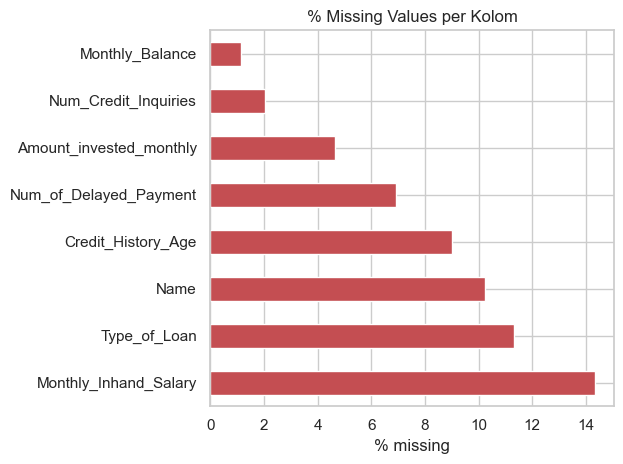

In [6]:
# Missing values (top 12)
na = df.isna().mean().sort_values(ascending=False)*100
na = na[na>0].head(12)
ax = na.plot(kind='barh', color='#c44e52')
ax.set_title('% Missing Values per Kolom'); ax.set_xlabel('% missing')
plt.tight_layout(); plt.show()

## 4. Preprocessing

Pembersihan diimplementasikan sebagai transformer sklearn **`CreditDataCleaner`**
(di `credit_features.py`) yang bersifat *row-independent* sehingga model bisa
dipakai untuk inferensi satu record. Langkahnya:
1. String kotor -> numerik (strip `_`, ganti garbage jadi NaN).
2. Feature engineering: `Credit_History_Age` ('X Years and Y Months') -> total bulan.
3. Outlier di luar rentang wajar -> NaN.
4. Placeholder kategorikal -> NaN.

Setelah itu `ColumnTransformer`: numerik diimputasi (median) + di-scale, kategorikal
diimputasi (modus) + one-hot encoding. Kelas `Preprocessor` di `pipeline.py`
membungkus semua ini.

In [7]:
from credit_features import CreditDataCleaner, NUM_COLS, CAT_COLS
cleaner = CreditDataCleaner()
clean = cleaner.transform(df.drop(columns=['Credit_Score']))
print('Kolom fitur setelah cleaning:', list(clean.columns))
print('\nContoh: Age & Annual_Income SEBELUM vs SESUDAH (5 baris pertama)')
comp = pd.DataFrame({
    'Age_raw': df['Age'].head(), 'Age_clean': clean['Age'].head(),
    'Income_raw': df['Annual_Income'].head(), 'Income_clean': clean['Annual_Income'].head(),
})
comp

Kolom fitur setelah cleaning: ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Credit_History_Age_Months', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

Contoh: Age & Annual_Income SEBELUM vs SESUDAH (5 baris pertama)


,Age_raw,Age_clean,Income_raw,Income_clean
0,8466,NaN,100433.58,100433.58
1,25,25.0,33119.82,33119.82
2,44,44.0,44822.21,44822.21
3,29,29.0,142081.48,142081.48
4,45,45.0,19267.27_,19267.27


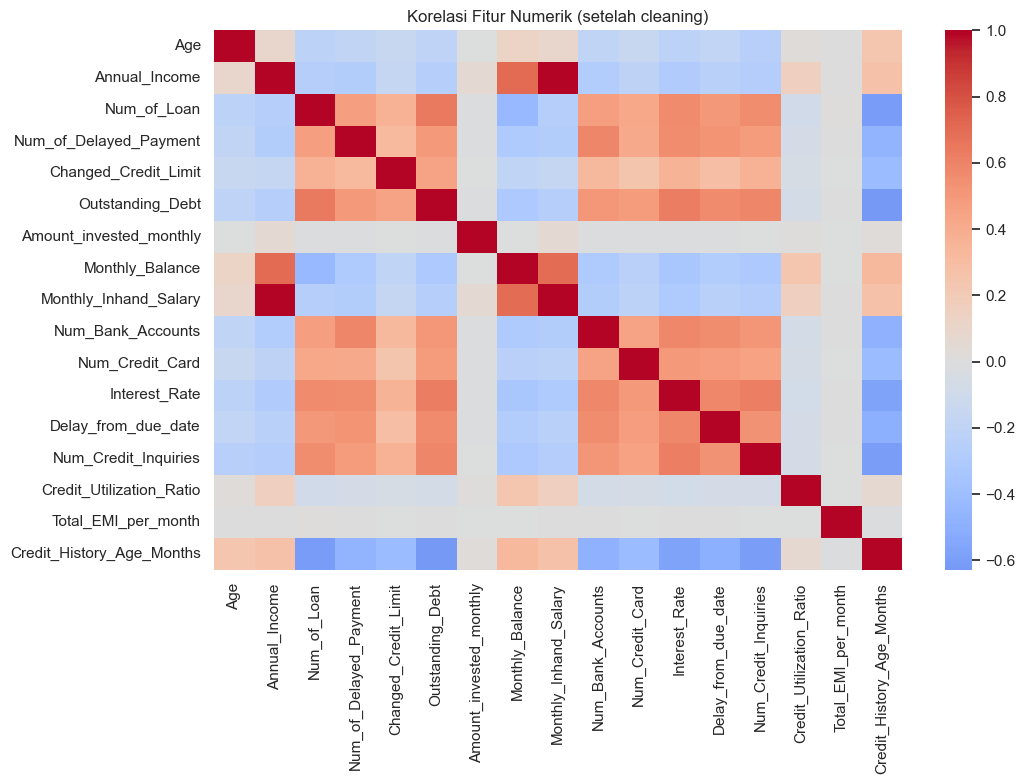

In [8]:
# Korelasi antar fitur numerik (setelah cleaning)
plt.figure(figsize=(11,8))
sns.heatmap(clean[NUM_COLS].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Korelasi Fitur Numerik (setelah cleaning)')
plt.tight_layout(); plt.show()

## 5. Modelling — Mencoba Beberapa Model

Kita mencoba **3 algoritma**: Logistic Regression (baseline linear),
Decision Tree, dan Random Forest. Tiap model memakai pipeline preprocessing yang
sama agar perbandingan adil. (Versi dengan tracking MLflow ada di `pipeline.py`.)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from pipeline import Preprocessor, ModelEvaluator

le = LabelEncoder()
y = le.fit_transform(df['Credit_Score'])
X = df.drop(columns=['Credit_Score'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
class_names = list(le.classes_)
print('Kelas:', class_names)

candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42),
}
evaluator = ModelEvaluator(class_names=class_names)
results, fitted = {}, {}
for name, est in candidates.items():
    pipe = Pipeline([('preprocessor', Preprocessor().build()), ('classifier', est)])
    pipe.fit(X_train, y_train)
    metrics, report, cm = evaluator.evaluate(pipe, X_test, y_test)
    results[name] = metrics; fitted[name] = (pipe, report, cm)
    print(f"{name}: acc={metrics['accuracy']:.4f}  f1_weighted={metrics['f1_weighted']:.4f}")
pd.DataFrame(results).T

Kelas: ['Good', 'Poor', 'Standard']


LogisticRegression: acc=0.6560  f1_weighted=0.6522


DecisionTree: acc=0.6942  f1_weighted=0.6954


RandomForest: acc=0.7410  f1_weighted=0.7409


,accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted
LogisticRegression,0.6560,0.652160,0.620349,0.655315,0.6560
DecisionTree,0.6942,0.695434,0.670658,0.698682,0.6942
RandomForest,0.7410,0.740918,0.717534,0.741314,0.7410


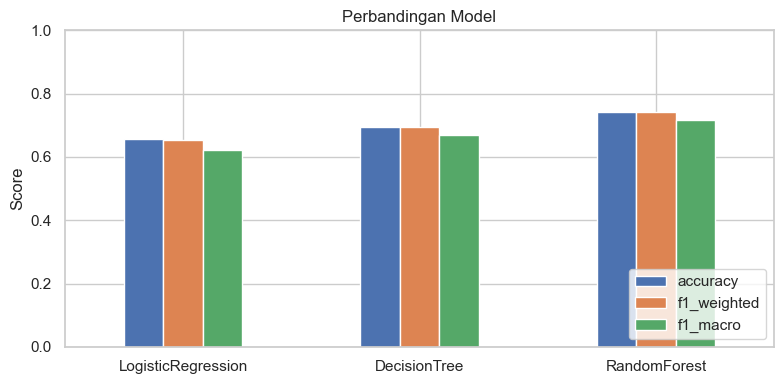

In [10]:
# Perbandingan model
res_df = pd.DataFrame(results).T[['accuracy','f1_weighted','f1_macro']]
ax = res_df.plot(kind='bar', figsize=(8,4))
ax.set_title('Perbandingan Model'); ax.set_ylabel('Score'); plt.xticks(rotation=0)
plt.ylim(0,1); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 6. Evaluasi Model Terbaik

In [11]:
best_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_pipe, best_report, best_cm = fitted[best_name]
print('MODEL TERBAIK:', best_name)
print(best_report)

MODEL TERBAIK: RandomForest
              precision    recall  f1-score   support

        Good       0.63      0.64      0.64       874
        Poor       0.76      0.72      0.74      1460
    Standard       0.77      0.79      0.78      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



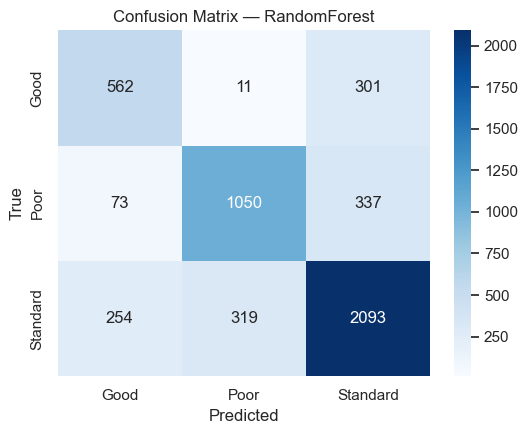

In [12]:
# Confusion matrix model terbaik
plt.figure(figsize=(5.5,4.5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

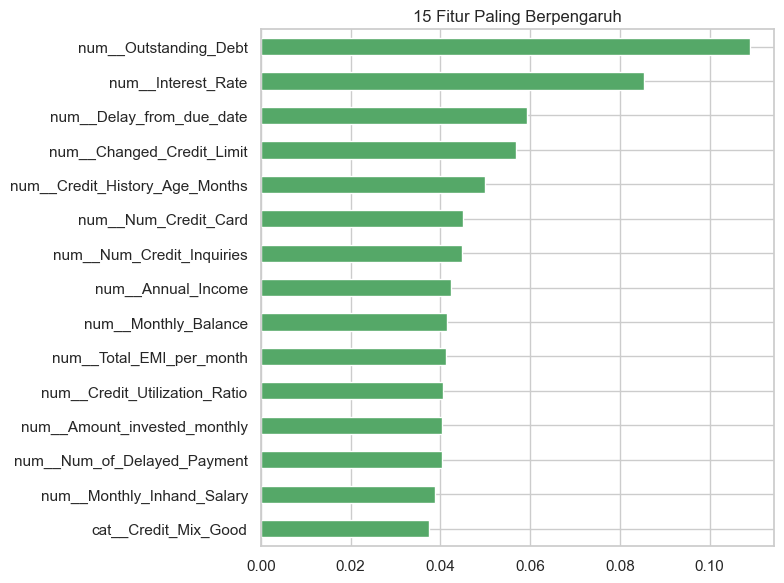

In [13]:
# Feature importance (Random Forest)
if best_name == 'RandomForest':
    pre = best_pipe.named_steps['preprocessor']
    feat_names = pre.named_steps['transform'].get_feature_names_out()
    imp = pd.Series(best_pipe.named_steps['classifier'].feature_importances_, index=feat_names)
    top = imp.sort_values(ascending=False).head(15)
    ax = top.iloc[::-1].plot(kind='barh', figsize=(8,6), color='#55a868')
    ax.set_title('15 Fitur Paling Berpengaruh'); plt.tight_layout(); plt.show()

## 7. Kesimpulan
- **Random Forest** memberi performa terbaik (akurasi ~74%, F1 weighted ~0.74),
  mengungguli Decision Tree dan Logistic Regression.
- Fitur paling berpengaruh umumnya: `Outstanding_Debt`, `Interest_Rate`,
  `Credit_Mix`, `Delay_from_due_date`, `Credit_History_Age_Months` — konsisten
  dengan intuisi risiko kredit.
- Model terbaik diserialisasi oleh `pipeline.py` ke `models/credit_score_model.pkl`
  (bundel berisi pipeline lengkap + label kelas), lalu dipakai oleh `inference.py`
  dan dideploy via Streamlit (`app.py`).

**Langkah selanjutnya:** pipeline lokal dengan MLflow (`pipeline.py`), deployment
web (Streamlit), dan migrasi ke AWS untuk skalabilitas (lihat folder `aws/`).